# Part 5 — Split Data (Anti-Leakage): DAIC-WOZ
**Pipeline**: Klasifikasi Kesehatan Mental Berbasis Audio (DAIC-WOZ)
**Peran**: ML & Data Engineer — Athila Ramdani Saputra

Notebook ini bertugas untuk:
1. Split dataset berdasarkan **Participant ID** (bukan per-segmen) → Anti-Leakage
2. Proposi: 70% Train / 15% Validation / 15% Test
3. Validasi tidak ada overlap Participant ID antar split
4. Fit StandardScaler **hanya pada train set** → transform val & test
5. Setup GroupKFold untuk cross-validation di Part 6
6. Simpan: `daic_train.csv`, `daic_val.csv`, `daic_test.csv`, `scaler.pkl`

**Kelas Target**: 0=Stress | 1=Kecemasan | 2=Depresi (via PHQ-8 proxy)
**KRITIS (Danylenko & Unold, 2025)**:
Semua sesi dari orang yang sama HARUS berada di split yang sama.


In [1]:
import os
import sys
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from sklearn.model_selection import GroupKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport.")


Library berhasil diimport.


## Konfigurasi Path


In [2]:
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.path.abspath(os.getcwd())

BASE_DIR      = os.path.dirname(os.path.dirname(current_dir))
PROCESSED_DIR = os.path.join(BASE_DIR, 'dataset', 'processed')
OUTPUT_DIR    = os.path.join(BASE_DIR, 'docs', 'assets', 'images', 'daic')
MODELS_DIR    = os.path.join(PROCESSED_DIR, 'models')

FEAT_FINAL_PATH  = os.path.join(PROCESSED_DIR, 'daic_features_final.csv')
FEAT_LIST_PATH   = os.path.join(PROCESSED_DIR, 'daic_feature_list.txt')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Proporsi Split
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_SEED = 42

print(f"Train / Val / Test  : {TRAIN_RATIO:.0%} / {VAL_RATIO:.0%} / {TEST_RATIO:.0%}")
print(f"Random Seed         : {RANDOM_SEED}")


Train / Val / Test  : 70% / 15% / 15%
Random Seed         : 42


## 5.1 — Load Dataset Final dari Part 4


In [3]:
df = pd.read_csv(FEAT_FINAL_PATH)

# Load daftar fitur
with open(FEAT_LIST_PATH, 'r') as f:
    FEAT_COLS = [line.strip() for line in f.readlines() if line.strip()]

# Pastikan semua fitur ada di dataframe
FEAT_COLS = [f for f in FEAT_COLS if f in df.columns]

META_COLS = ['participant_id', 'phq8_score', 'label_3kelas', 'severity']

print(f"Shape dataset final : {df.shape}")
print(f"Jumlah fitur        : {len(FEAT_COLS)}")
CLASS_NAMES = {0: 'Stress', 1: 'Kecemasan', 2: 'Depresi'}
print(f"\nDistribusi 3 Kelas:")
vc = df['label_3kelas'].value_counts().sort_index()
for label, count in vc.items():
    print(f"  Kelas {label} ({CLASS_NAMES.get(label,'?'):10s}): {count} ({count/len(df)*100:.1f}%)")


Shape dataset final : (188, 55)
Jumlah fitur        : 51

Distribusi 3 Kelas:
  Kelas 0 (Stress    ): 82 (43.6%)
  Kelas 1 (Kecemasan ): 90 (47.9%)
  Kelas 2 (Depresi   ): 16 (8.5%)


## 5.2 — Stratified Split Berbasis Participant ID

**Alur Anti-Leakage**:
1. Dapatkan daftar unik Participant ID
2. Split Participant ID secara stratified berdasarkan label
3. Map setiap Participant ke split yang sesuai

Dengan cara ini, seluruh sesi dari satu orang pasti di satu split saja.


In [4]:
# Dapatkan label per partisipan (1 partisipan = 1 baris = 1 label)
df_participants = df[['participant_id', 'label_3kelas']].drop_duplicates()
participant_ids    = df_participants['participant_id'].values
participant_labels = df_participants['label_3kelas'].values

print(f"Total partisipan unik: {len(participant_ids)}")

# Step 1: Split test set terlebih dahulu (15%)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_RATIO, random_state=RANDOM_SEED)
train_val_idx, test_idx = next(sss1.split(participant_ids, participant_labels))

pids_train_val = participant_ids[train_val_idx]
labels_train_val = participant_labels[train_val_idx]
pids_test = participant_ids[test_idx]

# Step 2: Split validation dari train_val (15% dari total ≈ 17.6% dari train_val)
val_size_relative = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size_relative, random_state=RANDOM_SEED)
train_idx2, val_idx2 = next(sss2.split(pids_train_val, labels_train_val))

pids_train = pids_train_val[train_idx2]
pids_val   = pids_train_val[val_idx2]

print(f"\nHasil Split (berdasarkan Participant ID):")
print(f"  Train : {len(pids_train)} partisipan ({len(pids_train)/len(participant_ids)*100:.1f}%)")
print(f"  Val   : {len(pids_val)} partisipan ({len(pids_val)/len(participant_ids)*100:.1f}%)")
print(f"  Test  : {len(pids_test)} partisipan ({len(pids_test)/len(participant_ids)*100:.1f}%)")


Total partisipan unik: 188

Hasil Split (berdasarkan Participant ID):
  Train : 130 partisipan (69.1%)
  Val   : 29 partisipan (15.4%)
  Test  : 29 partisipan (15.4%)


## 5.3 — Validasi Anti-Leakage
Memastikan **tidak ada Participant ID yang overlap** di antara train, val, dan test.


In [5]:
set_train = set(pids_train)
set_val   = set(pids_val)
set_test  = set(pids_test)

overlap_tv = set_train & set_val
overlap_tt = set_train & set_test
overlap_vt = set_val   & set_test

print("=== VALIDASI ANTI-LEAKAGE ===")
print(f"Overlap Train ∩ Val   : {len(overlap_tv)} partisipan  {'✓ AMAN' if len(overlap_tv)==0 else '✗ BAHAYA!'}")
print(f"Overlap Train ∩ Test  : {len(overlap_tt)} partisipan  {'✓ AMAN' if len(overlap_tt)==0 else '✗ BAHAYA!'}")
print(f"Overlap Val   ∩ Test  : {len(overlap_vt)} partisipan  {'✓ AMAN' if len(overlap_vt)==0 else '✗ BAHAYA!'}")

assert len(overlap_tv) == 0, "LEAKAGE TERDETEKSI: Train-Val overlap!"
assert len(overlap_tt) == 0, "LEAKAGE TERDETEKSI: Train-Test overlap!"
assert len(overlap_vt) == 0, "LEAKAGE TERDETEKSI: Val-Test overlap!"
print("\n✓ Validasi Anti-Leakage LULUS — Tidak ada Participant ID yang overlap.")


=== VALIDASI ANTI-LEAKAGE ===
Overlap Train ∩ Val   : 0 partisipan  ✓ AMAN
Overlap Train ∩ Test  : 0 partisipan  ✓ AMAN
Overlap Val   ∩ Test  : 0 partisipan  ✓ AMAN

✓ Validasi Anti-Leakage LULUS — Tidak ada Participant ID yang overlap.


## 5.4 — Buat DataFrame Train / Val / Test


In [6]:
df_train = df[df['participant_id'].isin(pids_train)].copy().reset_index(drop=True)
df_val   = df[df['participant_id'].isin(pids_val)].copy().reset_index(drop=True)
df_test  = df[df['participant_id'].isin(pids_test)].copy().reset_index(drop=True)

print("=== Distribusi Kelas per Split (3 Kelas) ===")
for name, dset in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    counts = dset['label_3kelas'].value_counts().sort_index()
    detail = ' | '.join([f"{CLASS_NAMES.get(k,'?')}={v}" for k,v in counts.items()])
    print(f"  [{name}] total={len(dset)} | {detail}")


=== Distribusi Kelas per Split (3 Kelas) ===
  [Train] total=130 | Stress=56 | Kecemasan=62 | Depresi=12
  [Val] total=29 | Stress=13 | Kecemasan=14 | Depresi=2
  [Test] total=29 | Stress=13 | Kecemasan=14 | Depresi=2


## 5.5 — StandardScaler (Fit HANYA pada Train)
Melanggar aturan ini (fit pada semua data) = data leakage statistik.


In [7]:
X_train = df_train[FEAT_COLS].values
X_val   = df_val[FEAT_COLS].values
X_test  = df_test[FEAT_COLS].values

y_train = df_train['label_3kelas'].values
y_val   = df_val['label_3kelas'].values
y_test  = df_test['label_3kelas'].values

# Fit scaler HANYA pada train set
scaler = StandardScaler()
scaler.fit(X_train)

# Transform semua split
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Masukkan kembali ke DataFrame
df_train_scaled = df_train[META_COLS].copy()
df_val_scaled   = df_val[META_COLS].copy()
df_test_scaled  = df_test[META_COLS].copy()

df_train_scaled[FEAT_COLS] = X_train_scaled
df_val_scaled[FEAT_COLS]   = X_val_scaled
df_test_scaled[FEAT_COLS]  = X_test_scaled

print("StandardScaler berhasil di-fit pada train set dan ditransform ke semua split.")
print(f"  Mean (train, 5 fitur pertama): {scaler.mean_[:5].round(4)}")
print(f"  Std  (train, 5 fitur pertama): {scaler.scale_[:5].round(4)}")


StandardScaler berhasil di-fit pada train set dan ditransform ke semua split.
  Mean (train, 5 fitur pertama): [143.3142  38.1694 -61.8869 168.9209   5.3099]
  Std  (train, 5 fitur pertama): [14.4241 10.6245 41.1107 16.0498 13.7301]


## 5.6 — Visualisasi Distribusi Split


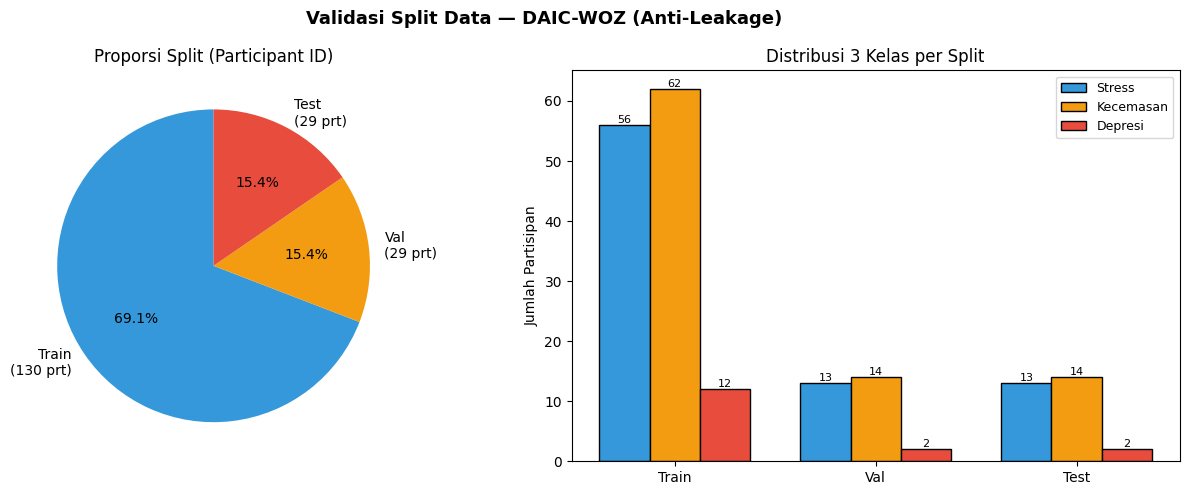

Visualisasi split tersimpan.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Validasi Split Data — DAIC-WOZ (Anti-Leakage)', fontsize=13, fontweight='bold')

# Pie chart pembagian partisipan
split_sizes  = [len(pids_train), len(pids_val), len(pids_test)]
split_labels = [f'Train\n({len(pids_train)} prt)', f'Val\n({len(pids_val)} prt)',
                f'Test\n({len(pids_test)} prt)']
axes[0].pie(split_sizes, labels=split_labels, autopct='%1.1f%%',
            colors=['#3498db', '#f39c12', '#e74c3c'], startangle=90,
            textprops={'fontsize': 10})
axes[0].set_title('Proporsi Split (Participant ID)')

# Bar chart distribusi 3 kelas per split
splits     = {'Train': df_train, 'Val': df_val, 'Test': df_test}
x          = np.arange(3)
width      = 0.25
class_colors = ['#3498db', '#f39c12', '#e74c3c']
for ci, (k, name) in enumerate(CLASS_NAMES.items()):
    counts = [int((dset['label_3kelas'] == k).sum()) for dset in splits.values()]
    bars   = axes[1].bar(x + (ci - 1) * width, counts, width,
                          label=name, color=class_colors[ci], edgecolor='black')
    for bar, val in zip(bars, counts):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     str(val), ha='center', fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Train', 'Val', 'Test'])
axes[1].set_ylabel('Jumlah Partisipan')
axes[1].set_title('Distribusi 3 Kelas per Split')
axes[1].legend(fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'p5_split_validation.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi split tersimpan.")


## 5.7 — Simpan Semua Output


In [9]:
# Simpan CSV
out_train = os.path.join(PROCESSED_DIR, 'daic_train.csv')
out_val   = os.path.join(PROCESSED_DIR, 'daic_val.csv')
out_test  = os.path.join(PROCESSED_DIR, 'daic_test.csv')

df_train_scaled.to_csv(out_train, index=False)
df_val_scaled.to_csv(out_val,   index=False)
df_test_scaled.to_csv(out_test,  index=False)

# Simpan scaler
scaler_path = os.path.join(MODELS_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

# Simpan daftar PID per split untuk referensi
split_info = {
    'train_pids': pids_train.tolist(),
    'val_pids'  : pids_val.tolist(),
    'test_pids' : pids_test.tolist(),
}
import json
split_info_path = os.path.join(PROCESSED_DIR, 'daic_split_info.json')
with open(split_info_path, 'w') as f:
    json.dump(split_info, f, indent=2)

print("=== SEMUA OUTPUT TERSIMPAN ===")
print(f"  Train CSV  : {out_train}  ({df_train_scaled.shape})")
print(f"  Val CSV    : {out_val}    ({df_val_scaled.shape})")
print(f"  Test CSV   : {out_test}   ({df_test_scaled.shape})")
print(f"  Scaler PKL : {scaler_path}")
print(f"  Split Info : {split_info_path}")


=== SEMUA OUTPUT TERSIMPAN ===
  Train CSV  : d:\repositories\menthealth-ml\dataset\processed\daic_train.csv  ((130, 55))
  Val CSV    : d:\repositories\menthealth-ml\dataset\processed\daic_val.csv    ((29, 55))
  Test CSV   : d:\repositories\menthealth-ml\dataset\processed\daic_test.csv   ((29, 55))
  Scaler PKL : d:\repositories\menthealth-ml\dataset\processed\models\scaler.pkl
  Split Info : d:\repositories\menthealth-ml\dataset\processed\daic_split_info.json


## 5.8 — Setup GroupKFold untuk Part 6 (Cross-Validation)

GroupKFold memastikan semua sesi dari orang yang sama berada di fold yang sama.
Ini adalah metode cross-validation yang aman untuk dataset audio medis.


In [10]:
# Demo setup GroupKFold pada data train
X_demo = df_train_scaled[FEAT_COLS].values
y_demo = df_train_scaled['label_3kelas'].values
groups = df_train_scaled['participant_id'].values

N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)

print(f"GroupKFold Cross-Validation Setup — {N_FOLDS} Folds")
print(f"{'Fold':<6} {'Train (prt)':<15} {'Val (prt)':<15} {'Train Dep%':<15} {'Val Dep%'}")
print("-" * 65)

for fold, (tr_idx, vl_idx) in enumerate(gkf.split(X_demo, y_demo, groups)):
    train_dep_pct = y_demo[tr_idx].mean() * 100
    val_dep_pct   = y_demo[vl_idx].mean() * 100
    # Jumlah partisipan unik per fold
    n_tr_grp = len(np.unique(groups[tr_idx]))
    n_vl_grp = len(np.unique(groups[vl_idx]))
    print(f"  {fold+1:<4} {n_tr_grp:<15} {n_vl_grp:<15} {train_dep_pct:<14.1f}% {val_dep_pct:.1f}%")

print(f"\n✓ GroupKFold siap digunakan di Part 6 (Training Model).")
print(f"  Pastikan gunakan groups=participant_id agar tidak terjadi leakage dalam CV.")

GroupKFold Cross-Validation Setup — 5 Folds
Fold   Train (prt)     Val (prt)       Train Dep%      Val Dep%
-----------------------------------------------------------------
  1    104             26              69.2          % 53.8%
  2    104             26              64.4          % 73.1%
  3    104             26              66.3          % 65.4%
  4    104             26              65.4          % 69.2%
  5    104             26              65.4          % 69.2%

✓ GroupKFold siap digunakan di Part 6 (Training Model).
  Pastikan gunakan groups=participant_id agar tidak terjadi leakage dalam CV.
